# 浮点数与稳定数值计算

第014单元。先修004、007、010；CPU、NumPy与本地原创合成配置。目标是把输入转换、计算路径、有限范围、消减和差分截断误差分开。请先完成lab.pdf纸笔问题。

## 设置

重新启动内核后从头运行。输出写入notebook_outputs；重复运行覆盖同目录的三个结果文件，不改data配置。没有网络、API或GPU依赖。

In [1]:
from pathlib import Path
import csv
import numpy as np
from IPython.display import Image, display
from experiment import (vector, format_info, naive_softmax, stable_distribution,
                        cancellation, central_exp, run)
for dtype in ("float32", "float64"):
    print(dtype, format_info(dtype))

float32 {'bits': 32, 'eps': 1.1920928955078125e-07, 'smallest_normal': 1.1754943508222875e-38, 'smallest_subnormal': 1.401298464324817e-45, 'max': 3.4028234663852886e+38, 'spacing_at_1': 1.1920928955078125e-07, 'spacing_at_2': 2.384185791015625e-07, 'one_plus_half_eps_equals_one': True}
float64 {'bits': 64, 'eps': 2.220446049250313e-16, 'smallest_normal': 2.2250738585072014e-308, 'smallest_subnormal': 5e-324, 'max': 1.7976931348623157e+308, 'spacing_at_1': 2.220446049250313e-16, 'spacing_at_2': 4.440892098500626e-16, 'one_plus_half_eps_equals_one': True}


## 1 查看已经存储的输入

同样的十进制分数转换后可能相同。先看存值，再判断后面的稳定公式。

float32 [1.e+08 1.e+08] difference 0.0
[0.5 0.5]
float64 [1.00000000e+08 1.00000001e+08] difference 1.0
[0.26894142 0.73105858]


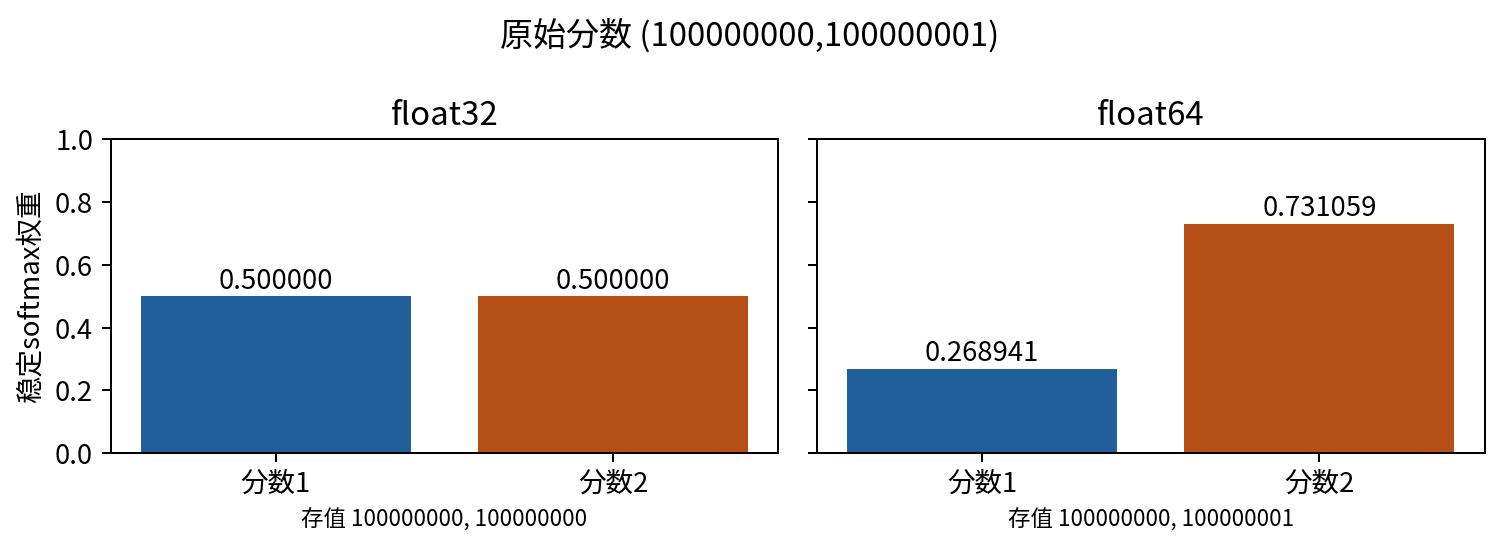

In [2]:
for dtype in ("float32", "float64"):
    stored = vector([100000000,100000001], dtype)
    print(dtype, stored, "difference", stored[1]-stored[0])
    print(stable_distribution(stored,dtype)["probabilities"])
display(Image(filename="figures/02_cast.png", width=740))

## 2 用朴素公式重现上溢和全下溢

它故意允许失败输出，以便检查哪一步出了问题；不要把NaN当0。

In [3]:
for dtype in ("float32", "float64"):
    for values in ([1000,1001,999],[-1000,-999,-1001]):
        result = naive_softmax(values,dtype)
        print(dtype, values, result, "all finite", np.isfinite(result).all())
        assert not np.isfinite(result).all()

float32 [1000, 1001, 999] [nan nan nan] all finite False
float32 [-1000, -999, -1001] [nan nan nan] all finite False
float64 [1000, 1001, 999] [nan nan nan] all finite False
float64 [-1000, -999, -1001] [nan nan nan] all finite False


## 3 平移后再归一化

所有指数不大于1，最大项为1。报告实际dtype与和，而不是只说运行正常。

float32 p [0.24472846 0.66524094 0.09003057] LSE 1001.4076
float64 p [0.24472847 0.66524096 0.09003057] LSE 1001.4076059644444


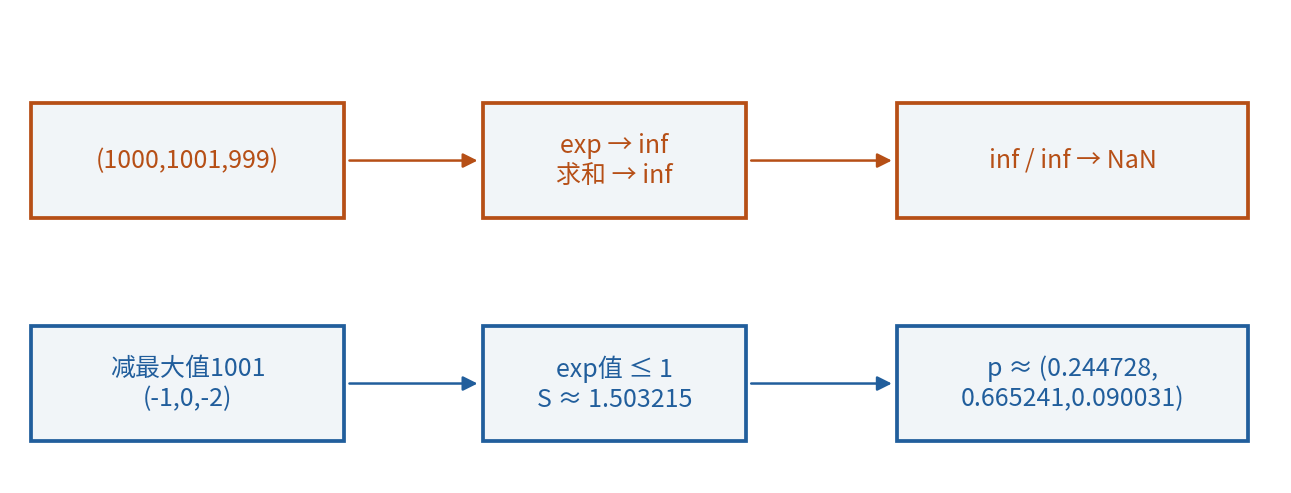

In [4]:
for dtype in ("float32", "float64"):
    result = stable_distribution([1000,1001,999],dtype)
    print(dtype, "p", result["probabilities"], "LSE", result["logsumexp"])
    assert np.isfinite(result["probabilities"]).all()
    assert abs(float(result["probabilities"].sum())-1)<1e-6
display(Image(filename="figures/05_softmax.png", width=740))

## 4 观察尾项和直接log权重

float32的尾概率可为零，直接稳定log表达式仍有限。

In [5]:
for dtype in ("float32", "float64"):
    result = stable_distribution([0,-200],dtype)
    print(dtype, result["probabilities"], result["log_probabilities"], result["zero_tail_terms"])
    assert np.isfinite(result["log_probabilities"]).all()

float32 [1. 0.] [   0. -200.] 1
float64 [1.00000000e+00 1.38389653e-87] [   0. -200.] 0


## 5 消减与有理化

参考使用当前dtype实际存储的x。接近零时须区分绝对误差和相对误差。

float32 {'stored_x': 9.999999747378752e-05, 'direct': 4.9948692321777344e-05, 'rationalized': 4.999874727218412e-05, 'reference': 4.9998748799453003e-05}
float32 {'stored_x': 9.99999993922529e-09, 'direct': 0.0, 'rationalized': 4.999999969612645e-09, 'reference': 4.999999957112646e-09}
float32 {'stored_x': 9.999999960041972e-13, 'direct': 0.0, 'rationalized': 4.999999980020986e-13, 'reference': 4.999999980019736e-13}
float32 {'stored_x': 1.0000000168623835e-16, 'direct': 0.0, 'rationalized': 5.0000000843119176e-17, 'reference': 5.0000000843119176e-17}
float64 {'stored_x': 0.0001, 'direct': 4.9998750062396624e-05, 'rationalized': 4.99987500624961e-05, 'reference': 4.99987500624961e-05}
float64 {'stored_x': 1e-08, 'direct': 4.999999969612645e-09, 'rationalized': 4.9999999875e-09, 'reference': 4.9999999875e-09}
float64 {'stored_x': 1e-12, 'direct': 5.000444502911705e-13, 'rationalized': 4.99999999999875e-13, 'reference': 4.99999999999875e-13}
float64 {'stored_x': 1e-16, 'direct': 0.0, 'ra

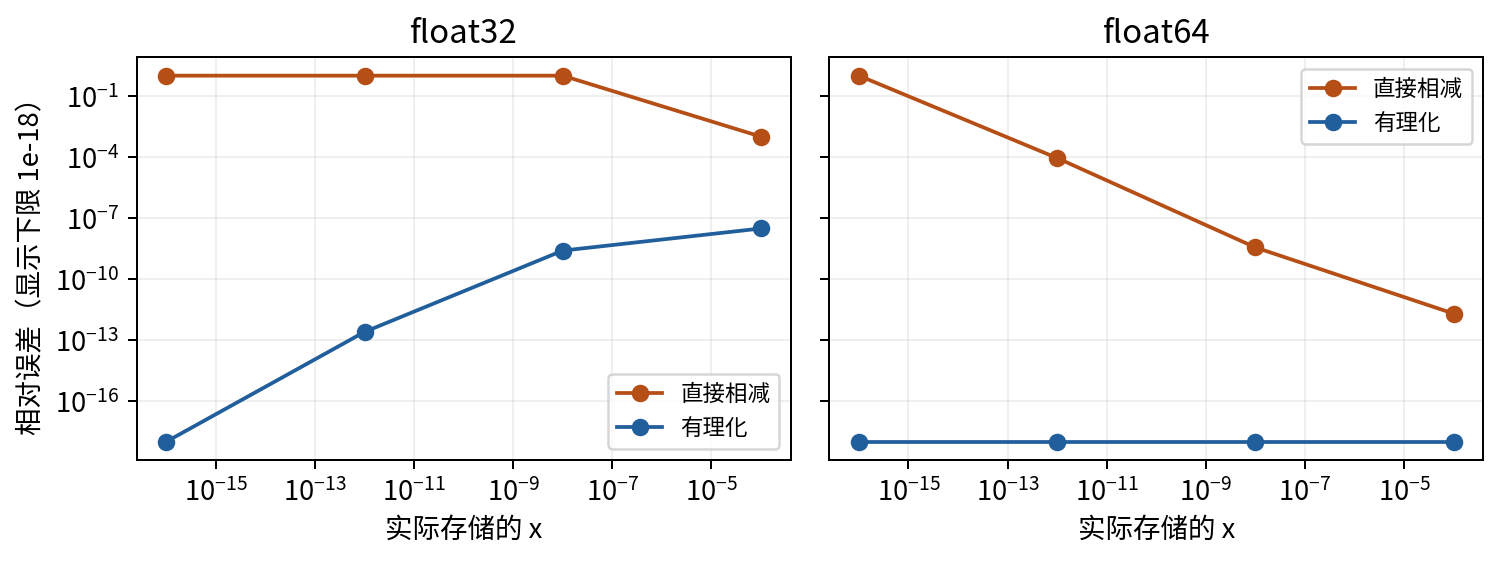

In [6]:
for dtype in ("float32", "float64"):
    for value in (1e-4,1e-8,1e-12,1e-16):
        result=cancellation(value,dtype)
        print(dtype,result)
assert cancellation(1e-16,"float64")["direct"] == 0
display(Image(filename="figures/04_cancellation.png", width=740))

## 6 同一导数的步长与dtype

每种dtype参考点不同。actual_plus_step与stored_h未必相等。

float32 {'value': 2.0137627124786377, 'reference': 2.0137526834646735, 'absolute_error': 1.0029013964185651e-05, 'stored_x': 0.699999988079071, 'stored_h': 0.003000000026077032, 'actual_plus_step': 0.003000020980834961, 'actual_minus_step': 0.003000020980834961}
float64 {'value': 2.0137527074970407, 'reference': 2.0137527074704766, 'absolute_error': 2.6564084265601196e-11, 'stored_x': 0.7, 'stored_h': 1e-05, 'actual_plus_step': 9.99999999995449e-06, 'actual_minus_step': 9.99999999995449e-06}
float32 rejected: Unresolvable input step
float64 rejected: Unresolvable input step


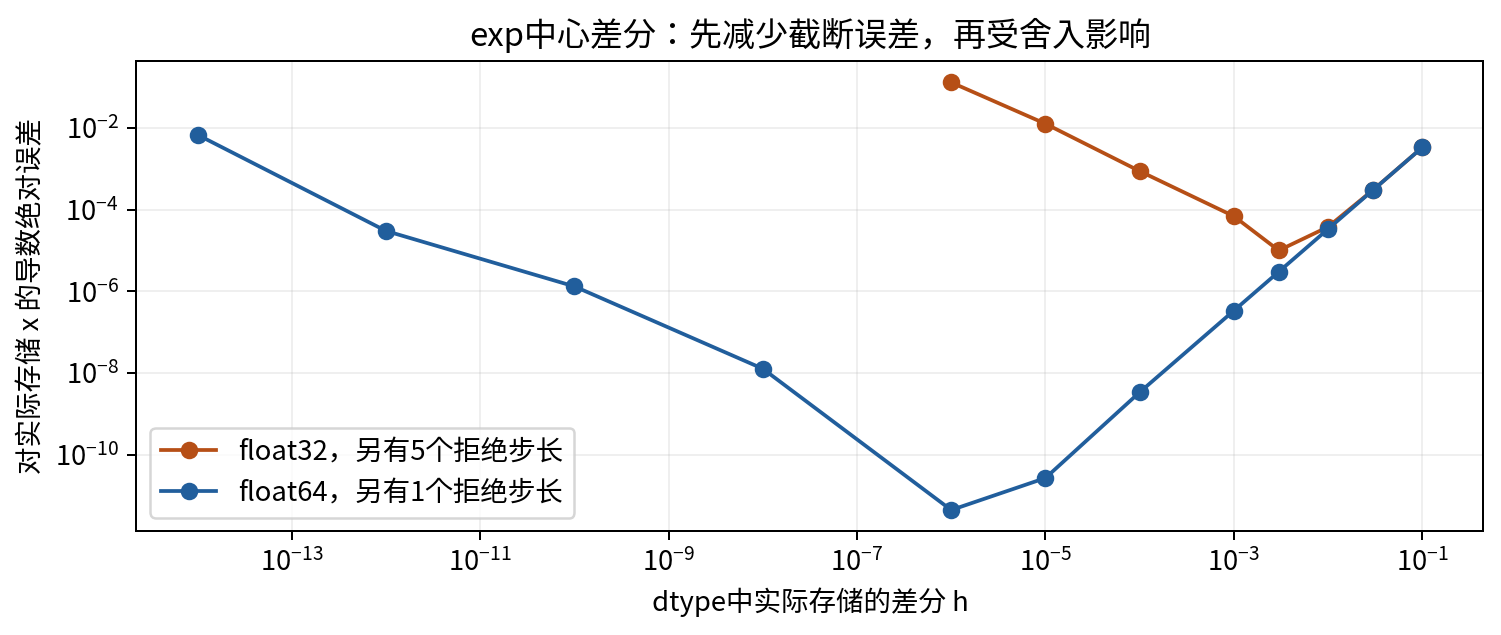

In [7]:
for dtype,h in (("float32",0.003),("float64",1e-5)):
    print(dtype,central_exp(0.7,h,dtype))
for dtype in ("float32","float64"):
    try:
        central_exp(0.7,1e-17,dtype)
    except ArithmeticError as error:
        print(dtype, "rejected:", str(error))
    else:
        raise AssertionError("Indistinguishable sample accepted")
display(Image(filename="figures/06_difference.png", width=740))

## 7 三个合法但不同的数值现象

加法顺序错误可以保持有限；输入转换也可能保持有限；尾项下溢可能让归一化总和仍为1。

In [8]:
a,b,c=np.float64(1e16),np.float64(-1e16),np.float64(1)
print("left",(a+b)+c,"right",a+(b+c))
assert (a+b)+c==1 and a+(b+c)==0
small=stable_distribution([0,-200],"float32")
assert small["probabilities"].sum()==1
assert small["probabilities"][1]==0

left 1.0 right 0.0


## 8 独立参考和失败测试

200个向量dtype案例使用110位Decimal直接指数求和；另有导数、共轭公式、Fraction恒等式及非法输入检查。

In [9]:
from test_experiment import tests
checks=tests()
print(checks)
assert checks["status"]=="passed"

{'status': 'passed', 'groups': 9, 'details': ['exact format eps spacing and tie-to-even checks', '100 random vectors times two dtypes against independent 110-digit Decimal and exact shifts', 'overflow all-zero underflow and finite log-tail cases', 'input casting loses score difference before stable formula', 'rationalized sqrt Decimal reference including zero and domain endpoint', '82 independent exp derivative references and nine exact cubic difference identities', '23 invalid shape type domain range and step cases; source array unchanged', 'associativity counterexample and byte-identical repeated complete runs', '6 document Python snippets execute in order'], 'random_vector_fixtures': 100, 'dtype_cases': 200, 'rejected_cases': 23, 'python_snippets': 6}


## 9 保存并对照脚本输出

扫描包含失败行，不把空误差当零；三文件与随附脚本输出逐字节一致。

In [10]:
report=run(Path("notebook_outputs"))
for name in ("results.json","difference_scan.csv","environment.json"):
    assert (Path("notebook_outputs")/name).read_bytes()==(Path("outputs")/name).read_bytes()
rows=list(csv.DictReader((Path("notebook_outputs")/"difference_scan.csv").open()))
for dtype in ("float32","float64"):
    selected=[row for row in rows if row["dtype"]==dtype]
    good=[row for row in selected if row["status"]=="computed"]
    best=min(good,key=lambda row:float(row["absolute_error"]))
    print(dtype,"best observed",best["requested_h"],best["absolute_error"],"rejected",len(selected)-len(good))

float32 best observed 0.003 1.0029013964185651e-05 rejected 5
float64 best observed 1e-06 4.359623773098065e-12 rejected 1


## 下一步

回答lecture.pdf的12道问题，使用answers.pdf核对条件。最佳扫描步长只属于这组函数、位置、dtype与实现。已验证新进程真实InProcessKernel顺序执行；未测试Jupyter浏览器、跨进程socket、全新Anaconda或其他硬件。没有实际训练或性能结论。原始来源见source-checks.json。